In [2]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

def create_personalized_iap_packs_model_dataset(base_path):
    """
    Create a dataset for modeling the personalized iap packs model.
    """
    print("Kişiselleştirilmiş iap paketleri veri seti oluşturma süreci başladı...")

    # --- 1. Veri Yükleme ---
    print("📂 Ham veri dosyaları yükleniyor...")

    required_files = {
        "demographics": "demographics.xlsx",
        "iap_data": "iap_data.xlsx",
        "session_data": "session_data.xlsx",
        "level_completion_rate": "level_completion_rate_v2.xlsx",
    }

    # Load each file, and handle missing ones gracefully
    try:
        demographics = pd.read_excel(os.path.join(base_path, required_files["demographics"]))
        iap_data = pd.read_excel(os.path.join(base_path, required_files["iap_data"]))
        session_data =  pd.read_excel(os.path.join(base_path, required_files["session_data"]))
        level_completion_rate = pd.read_excel(os.path.join(base_path, required_files["level_completion_rate"]))
     
    except FileNotFoundError as e:
        print(f"❌ HATA: Gerekli bir dosya bulunamadı -> {e.filename}")
        return None

    # --- 2. Veri Birleştirme ---
    print("🔗 Veri setleri birleştiriliyor...")
    dataframes = [
        iap_data,session_data,level_completion_rate
    ]
    merged_df = demographics
    for df in dataframes:
        merged_df = pd.merge(merged_df, df, on='user_key_id', how='left')

    print("✅ Birleştirme tamamlandı.")
    return merged_df


In [3]:
base_path = "../../data/raw"
merged_df = create_personalized_iap_packs_model_dataset(base_path)

if merged_df is not None:
    display(merged_df.head())


Kişiselleştirilmiş iap paketleri veri seti oluşturma süreci başladı...
📂 Ham veri dosyaları yükleniyor...
🔗 Veri setleri birleştiriliyor...
✅ Birleştirme tamamlandı.


,user_key_id,country,age,sex,total_spent_in_usd,total_spent_time,session_count,total_session_time,easy_completion_rate,medium_completion_rate,hard_completion_rate
0,bVas4SMsXQ,GB,30.0,1.0,14.0,3.0,86.0,52464.0,100.0,100.0,25.0
1,08jRAlDfJC,US,70.0,1.0,NaN,NaN,NaN,NaN,100.0,25.0,0.0
2,QujP57B9cB,DE,NaN,NaN,NaN,NaN,NaN,NaN,100.0,75.0,0.0
3,Hm917zE2Mc,GB,36.0,0.0,16.8,4.0,10.0,4202.0,100.0,50.0,0.0
4,wFfzWC1Ydt,US,40.0,1.0,NaN,NaN,62.0,75586.0,100.0,100.0,0.0


In [4]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5100.0,39.822549,11.231648,18.0,32.0,39.0,47.00,9.900000e+01
sex,5049.0,0.573579,0.575331,0.0,0.0,1.0,1.00,2.000000e+00
total_spent_in_usd,1282.0,9.842987,11.006440,1.4,4.0,4.0,14.00,8.430002e+01
total_spent_time,1282.0,2.226989,2.713621,1.0,1.0,1.0,3.00,2.300000e+01
session_count,5206.0,27.005570,52.499985,1.0,2.0,7.0,27.00,6.240000e+02
total_session_time,5206.0,43371.198233,106957.365393,0.0,1838.0,8536.0,38571.75,1.699008e+06
easy_completion_rate,6877.0,91.144394,19.089566,50.0,100.0,100.0,100.00,1.000000e+02
medium_completion_rate,6877.0,45.539479,38.647225,0.0,0.0,50.0,75.00,1.000000e+02
hard_completion_rate,6877.0,4.407809,12.680386,0.0,0.0,0.0,0.00,1.000000e+02


In [5]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             8763 non-null   object 
 1   country                 8763 non-null   object 
 2   age                     5100 non-null   float64
 3   sex                     5049 non-null   float64
 4   total_spent_in_usd      1282 non-null   float64
 5   total_spent_time        1282 non-null   float64
 6   session_count           5206 non-null   float64
 7   total_session_time      5206 non-null   float64
 8   easy_completion_rate    6877 non-null   float64
 9   medium_completion_rate  6877 non-null   float64
 10  hard_completion_rate    6877 non-null   float64
dtypes: float64(9), object(2)
memory usage: 753.2+ KB


In [7]:
# Filter out users who don't have session_count (i.e., where it's NaN)
filtered_df = merged_df[merged_df['session_count'].notna()]
filtered_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5206 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             5206 non-null   object 
 1   country                 5206 non-null   object 
 2   age                     3715 non-null   float64
 3   sex                     3691 non-null   float64
 4   total_spent_in_usd      1182 non-null   float64
 5   total_spent_time        1182 non-null   float64
 6   session_count           5206 non-null   float64
 7   total_session_time      5206 non-null   float64
 8   easy_completion_rate    4643 non-null   float64
 9   medium_completion_rate  4643 non-null   float64
 10  hard_completion_rate    4643 non-null   float64
dtypes: float64(9), object(2)
memory usage: 488.1+ KB


In [8]:
# Map the 'sex' column: 0 -> 'Women', 1 -> 'Men'
filtered_df['sex'] = filtered_df['sex'].map({0: 'Women', 1: 'Men'})

filtered_df.head()

/var/folders/4g/k36svxd51cxdn1qcwnzvrbsc0000gn/T/ipykernel_25721/2574785056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['sex'] = filtered_df['sex'].map({0: 'Women', 1: 'Men'})


,user_key_id,country,age,sex,total_spent_in_usd,total_spent_time,session_count,total_session_time,easy_completion_rate,medium_completion_rate,hard_completion_rate
0,bVas4SMsXQ,GB,30.0,Men,14.0,3.0,86.0,52464.0,100.0,100.0,25.0
3,Hm917zE2Mc,GB,36.0,Women,16.8,4.0,10.0,4202.0,100.0,50.0,0.0
4,wFfzWC1Ydt,US,40.0,Men,NaN,NaN,62.0,75586.0,100.0,100.0,0.0
5,73S29MCQWv,DE,NaN,NaN,NaN,NaN,13.0,23024.0,100.0,75.0,0.0
7,B4A9tTZMAE,US,21.0,Women,NaN,NaN,2.0,983.0,100.0,0.0,0.0


In [9]:
# Calculate the count and rate of each gender
gender_counts = filtered_df['sex'].value_counts(dropna=True)
gender_rate = (gender_counts / gender_counts.sum()) * 100

# Combine both count and rate into a DataFrame
gender_stats = pd.DataFrame({
    'Count': gender_counts,
    'Rate (%)': gender_rate.round(2)
})

gender_stats

,Count,Rate (%)
sex,,
Men,1835,51.88
Women,1702,48.12


In [10]:
# Create a copy of the DataFrame to preserve the original
df_sex_imputed = filtered_df.copy()

# Get current distribution of 'sex' values
sex_distribution = df_sex_imputed['sex'].value_counts(normalize=True)

# Get indices where 'sex' is NaN
nan_indices = df_sex_imputed[df_sex_imputed['sex'].isna()].index

# Randomly assign 'Men' or 'Women' based on the observed distribution
imputed_values = np.random.choice(
    sex_distribution.index,
    size=len(nan_indices),
    p=sex_distribution.values
)

# Fill the NaN values
df_sex_imputed.loc[nan_indices, 'sex'] = imputed_values

df_sex_imputed['sex'].info()

df_sex_imputed.info()




<class 'pandas.core.series.Series'>
Index: 5206 entries, 0 to 8762
Series name: sex
Non-Null Count  Dtype 
--------------  ----- 
5206 non-null   object
dtypes: object(1)
memory usage: 210.4+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 5206 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             5206 non-null   object 
 1   country                 5206 non-null   object 
 2   age                     3715 non-null   float64
 3   sex                     5206 non-null   object 
 4   total_spent_in_usd      1182 non-null   float64
 5   total_spent_time        1182 non-null   float64
 6   session_count           5206 non-null   float64
 7   total_session_time      5206 non-null   float64
 8   easy_completion_rate    4643 non-null   float64
 9   medium_completion_rate  4643 non-null   float64
 10  hard_completion_rate    4643 non-null   float64
dtypes: float6

In [25]:
median_age = df_sex_imputed['age'].median()
mean_age = df_sex_imputed['age'].mean()
print(f"MedianAge: {median_age} , MeanAge: {mean_age}")

MedianAge: 39.0 , MeanAge: 39.765037593984964


In [11]:
df_age_imputed = df_sex_imputed.copy()
df_age_imputed['age'] = df_age_imputed.groupby('sex')['age'].transform(lambda x: x.fillna(x.median()))

In [12]:
df_age_imputed.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5206.0,39.549750,9.276359,18.0,36.0,39.0,43.00,9.900000e+01
total_spent_in_usd,1182.0,9.959738,11.026291,1.4,4.0,4.0,14.00,8.430002e+01
total_spent_time,1182.0,2.247039,2.719744,1.0,1.0,1.0,3.00,2.300000e+01
session_count,5206.0,27.005570,52.499985,1.0,2.0,7.0,27.00,6.240000e+02
total_session_time,5206.0,43371.198233,106957.365393,0.0,1838.0,8536.0,38571.75,1.699008e+06
easy_completion_rate,4643.0,93.937110,16.323090,50.0,100.0,100.0,100.00,1.000000e+02
medium_completion_rate,4643.0,53.542968,38.084715,0.0,25.0,50.0,100.00,1.000000e+02
hard_completion_rate,4643.0,5.537907,14.068065,0.0,0.0,0.0,0.00,1.000000e+02


In [13]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5206 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             5206 non-null   object 
 1   country                 5206 non-null   object 
 2   age                     5206 non-null   float64
 3   sex                     5206 non-null   object 
 4   total_spent_in_usd      1182 non-null   float64
 5   total_spent_time        1182 non-null   float64
 6   session_count           5206 non-null   float64
 7   total_session_time      5206 non-null   float64
 8   easy_completion_rate    4643 non-null   float64
 9   medium_completion_rate  4643 non-null   float64
 10  hard_completion_rate    4643 non-null   float64
dtypes: float64(8), object(3)
memory usage: 617.1+ KB


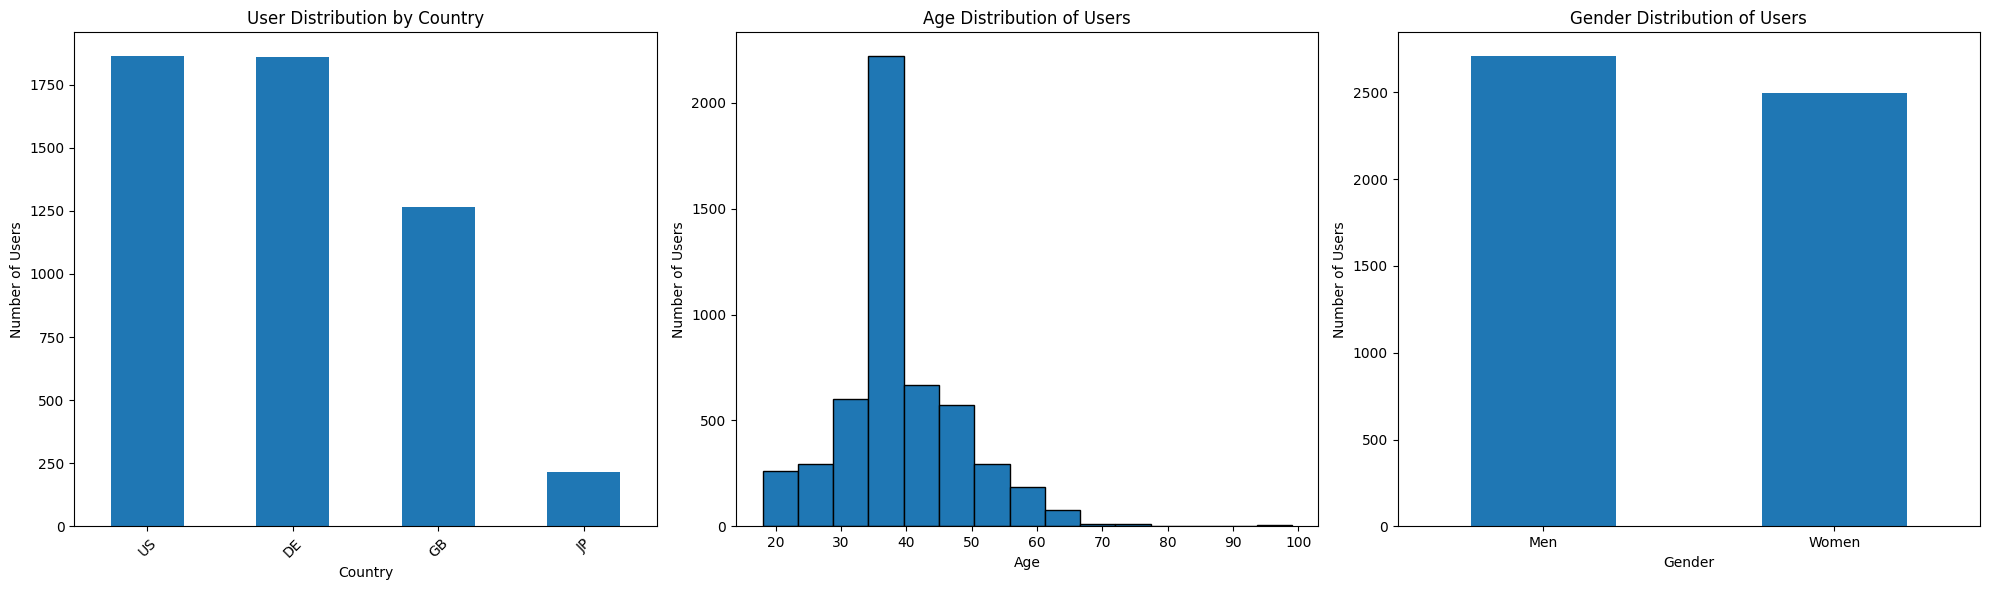

In [15]:
import matplotlib.pyplot as plt

# Creating subplots to show all three demographics in one figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# Updating country values based on the user's rules
df_age_imputed['country'] = df_age_imputed['country'].replace({
    'ES': 'DE',
    'FR': 'DE',
    'KR': 'JP',
    'LU': 'JP',
    'TZ': 'JP'
})


# Country distribution
df_age_imputed['country'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('User Distribution by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
df_age_imputed['age'].plot(kind='hist', bins=15, edgecolor='black', ax=axes[1])
axes[1].set_title('Age Distribution of Users')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Users')

# Gender distribution
df_age_imputed['sex'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Gender Distribution of Users')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Number of Users')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


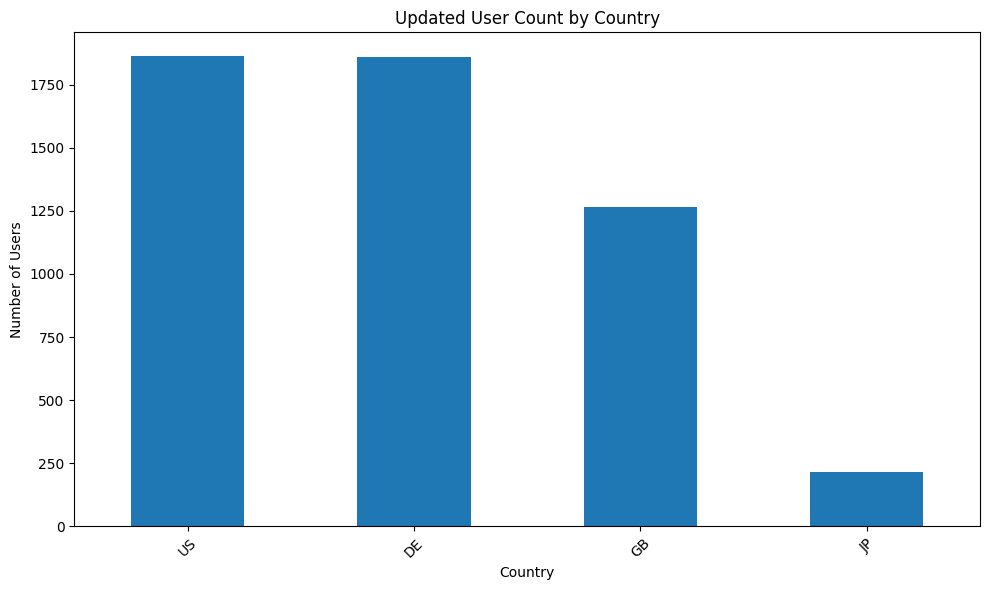

In [16]:
# Updating country values based on the user's rules
df_age_imputed['country'] = df_age_imputed['country'].replace({
    'ES': 'DE',
    'FR': 'DE',
    'KR': 'JP',
    'LU': 'JP',
    'TZ': 'JP'
})

# Recalculating user count by country after the update
updated_user_count_by_country = df_age_imputed['country'].value_counts().reset_index()
updated_user_count_by_country.columns = ['country', 'user_count']

# Display updated chart
plt.figure(figsize=(10, 6))
updated_user_count_by_country.set_index('country')['user_count'].plot(kind='bar')
plt.title('Updated User Count by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/4g/k36svxd51cxdn1qcwnzvrbsc0000gn/T/ipykernel_25721/1038338469.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_age_imputed.groupby(['country', 'age_category']).size().unstack(fill_value=0)


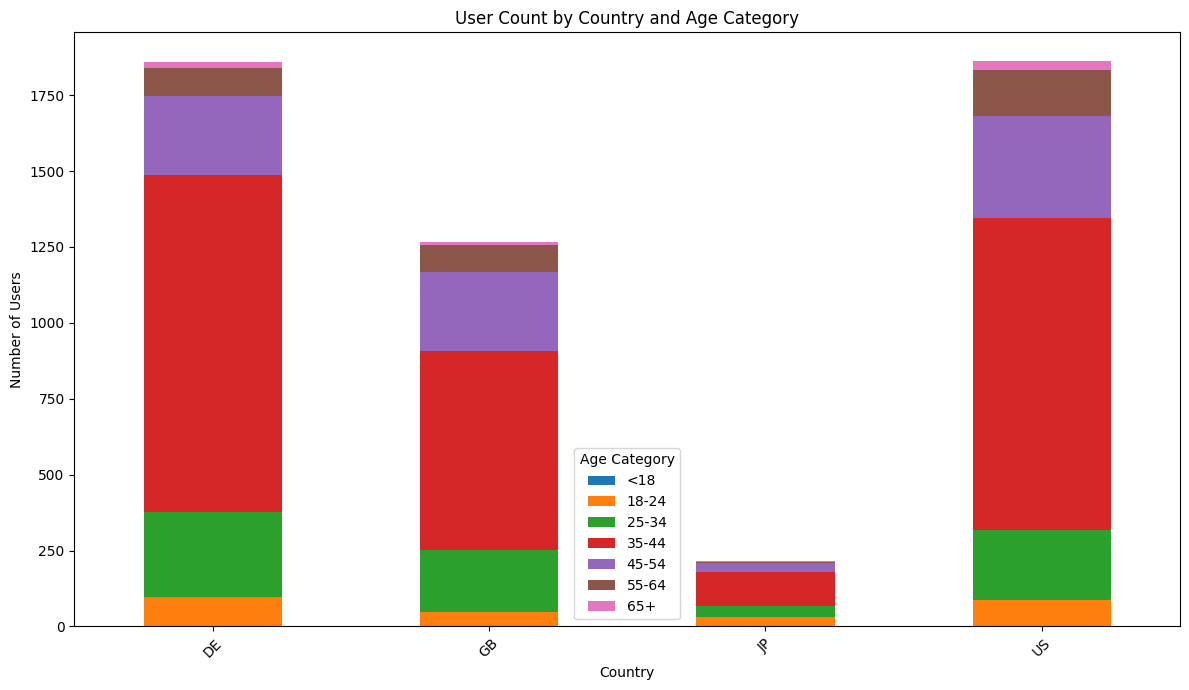

In [17]:
# Define age categories
bins = [0, 17, 24, 34, 44, 54, 64, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_age_imputed['age_category'] = pd.cut(df_age_imputed['age'], bins=bins, labels=labels, right=False)

# Group by country and age category
grouped = df_age_imputed.groupby(['country', 'age_category']).size().unstack(fill_value=0)

# Plotting a stacked bar chart
grouped.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('User Count by Country and Age Category')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Age Category')
plt.tight_layout()
plt.show()

In [18]:
# Remove the 'age_category' column from the dataframe
df_age_imputed.drop(columns=['age_category'], inplace=True)

# Confirm it's removed by showing the current columns
df_age_imputed.columns

Index(['user_key_id', 'country', 'age', 'sex', 'total_spent_in_usd',
       'total_spent_time', 'session_count', 'total_session_time',
       'easy_completion_rate', 'medium_completion_rate',
       'hard_completion_rate'],
      dtype='object')

In [19]:
# Fill NaN values in 'total_spent_in_usd' and 'total_spent_time' with 0
df_age_imputed[['total_spent_in_usd', 'total_spent_time']] = df_age_imputed[['total_spent_in_usd', 'total_spent_time']].fillna(0)

# Check that there are no more nulls in those columns
df_age_imputed[['total_spent_in_usd', 'total_spent_time']].isnull().sum()

total_spent_in_usd    0
total_spent_time      0
dtype: int64

In [20]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5206 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             5206 non-null   object 
 1   country                 5206 non-null   object 
 2   age                     5206 non-null   float64
 3   sex                     5206 non-null   object 
 4   total_spent_in_usd      5206 non-null   float64
 5   total_spent_time        5206 non-null   float64
 6   session_count           5206 non-null   float64
 7   total_session_time      5206 non-null   float64
 8   easy_completion_rate    4643 non-null   float64
 9   medium_completion_rate  4643 non-null   float64
 10  hard_completion_rate    4643 non-null   float64
dtypes: float64(8), object(3)
memory usage: 617.1+ KB


In [21]:
# Filter out users who don't have easy_completion_rate (i.e., where it's NaN)
filtered_final_row_data = df_age_imputed[df_age_imputed['easy_completion_rate'].notna()]
filtered_final_row_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4643 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_key_id             4643 non-null   object 
 1   country                 4643 non-null   object 
 2   age                     4643 non-null   float64
 3   sex                     4643 non-null   object 
 4   total_spent_in_usd      4643 non-null   float64
 5   total_spent_time        4643 non-null   float64
 6   session_count           4643 non-null   float64
 7   total_session_time      4643 non-null   float64
 8   easy_completion_rate    4643 non-null   float64
 9   medium_completion_rate  4643 non-null   float64
 10  hard_completion_rate    4643 non-null   float64
dtypes: float64(8), object(3)
memory usage: 435.3+ KB


In [23]:
base_processed_path = "../../data/processed/personalized_iap_pack_model"
filtered_final_row_data.to_excel(os.path.join(base_processed_path, "filtered_final_ml_excel_personalized_iap_pack_model.xlsx"), index=False)
filtered_final_row_data.to_csv(os.path.join(base_processed_path, "filtered_final_ml_excel_personalized_iap_pack_model.csv"), index=False)

In [40]:
base_processed_path = "../../data/processed/personalized_difficulty_model"
df_cluster.to_excel(os.path.join(base_processed_path, "filtered_final_ml_excel_personalized_difficulty_model_for_ml.xlsx"), index=False)
df_cluster.to_csv(os.path.join(base_processed_path, "filtered_final_ml_excel_personalized_difficulty_model_for_ml.csv"), index=False)